# Fig3_attention.ipynb

## Introduction
This notebook processes species attention scores in relation to multiple environmental factors. It includes:
1. Calculating overall attention scores.
2. Sorting and visualizing the environmental factor weights.
3. Investigating forest vs non-forest species distinctions.
4. Assessing relationships between attention scores and average elevation.

In [1]:
# Import necessary libraries and modules.
# The PlotUtlis class, create_folder, mm2inch, and set_mpl_defaults come from the Utils.py script.
# They provide helper functionalities such as figure styling, directory creation, and data manipulation.

from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail, reorder_df_attention, get_significance_stars
import pandas as pd
import copy
from matplotlib import font_manager as fm
import h5py
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

# Set default plotting parameters (e.g., fonts, axes, etc.)
set_mpl_defaults()

### Translate species name to Chinese

In [2]:
def get_chinese_sciname(target_name):
    change_names = {
    'Anas_zonorhyncha': 'Anas_poecilorhyncha', 
    'Cyanoderma_ruficeps': 'Stachyridopsis_ruficeps', 
    'Erythrogenys_erythrocnemis': 'Pomatorhinus_erythrocnemis', 
    'Ictinaetus_malaiensis': 'Ictinaetus_malayensis', 
    'Lewinia_striata': 'Gallirallus_striatus', 
    'Machlolophus_holsti': 'Parus_holsti', 
    'Pterorhinus_poecilorhynchus': 'Garrulax_poecilorhynchus', 
    'Pterorhinus_ruficeps': 'Garrulax_ruficeps', 
    'Schoeniparus_brunneus': 'Alcippe_brunnea', 
    'Sittiparus_castaneoventris': 'Poecile_varius', 
    'Synoicus_chinensis': 'Coturnix_chinensis', 
    'Taenioptynx_brodiei': 'Glaucidium_brodiei', 
    'Tarsiger_formosanus': 'Tarsiger_indicus', 
    'Turdus_niveiceps': 'Turdus_poliocephalus', 
    'Zapornia_fusca': 'Porzana_fusca'
    }
    df_name = pd.read_csv('../2023臺灣鳥類名錄-20230419.csv')
    for (new_name, orig_name) in change_names.items():
        if target_name == orig_name:
            target_name = new_name
            
    df_target = df_name[df_name['學名'] == target_name.replace('_', ' ')]
    return df_target['中文名'].values[0]

In [3]:
# Define run_id and exp_id for referencing the appropriate directories and configurations.
run_id = '144fa175d5d1428cb9b434cd1a0024f8'
exp_id = '625518819310735286'

In [4]:
# Instantiate PlotUtlis with the given run_id and exp_id.
# This object offers various methods for data loading and path management.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [5]:
# Create output folder paths for storing attention-related plots.
create_folder(PU.plot_path_attention)

### Calculate attention score of each species 

In [6]:
# Create a DataFrame of attention scores for each species, using PlotUtlis method.
# This averages the attention across all relevant dates. The method internally handles reading the data from h5 files.

df_attention = PU.create_attention_df()
df_attention.to_csv(PU.df_attention_path)

### Sort the attention weights for each environmental factor

In [7]:
# Reads the attention DataFrame from a saved CSV file. Then sums across species for each factor.
# Sort factors by total attention.

df_attention = pd.read_csv(PU.df_attention_path, index_col = 0)
df_attention_sumsort = df_attention.sum().sort_values()
df_attention_sumsort.index = convert_to_env_list_detail(df_attention_sumsort.index)
df_attention_sumsort

Precipitation           4.490055
LandcoverPC2            5.726122
Shortwave radiation     7.471685
Wind speed              8.039599
Temperature             9.251382
Cloud area fraction    12.161973
LandcoverPC4           13.410958
EVI                    14.632436
LandcoverPC1           15.399467
Relative humidity      16.090334
LandcoverPC3           18.325989
dtype: float64

### BAR PLOT

In [8]:
# Reorder the attention DataFrame so it can be plotted in a stacked bar chart.
df_attention_order = reorder_df_attention(df_attention)
species_list_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
df_attention_order = df_attention_order[~df_attention_order.index.isin([sp.replace('_', ' ') for sp in species_list_exclude])]

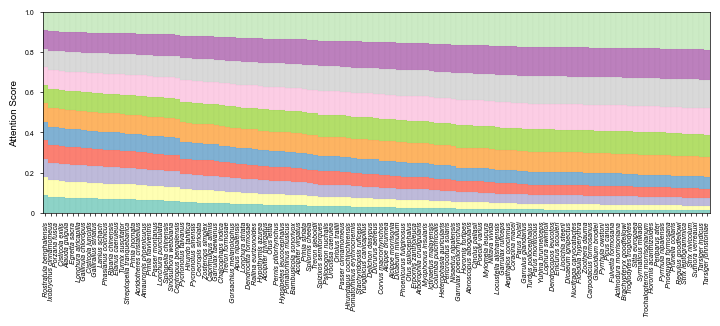

In [9]:
# Create a custom color map for the stacked bar plot.
# Plot stacked bars to visualize the contribution of each environmental factor per species.

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 80), constrained_layout = True)

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

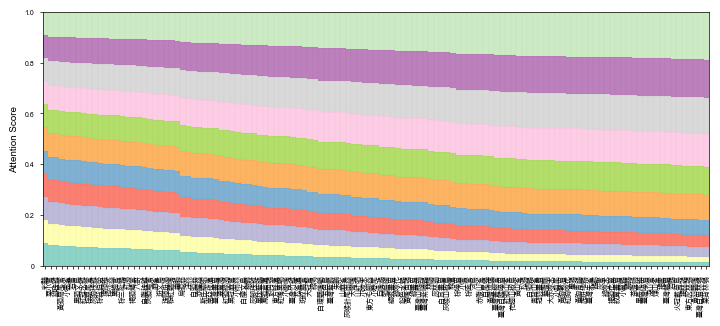

In [10]:
from matplotlib import font_manager as fm

font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_prop = fm.FontProperties(fname=font_path)

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 80), constrained_layout = True)

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
ax.set_xticklabels([get_chinese_sciname(sp.replace(' ', '_')) for sp in df_attention_order.index], ha='center', va='top', fontstyle='italic', fontproperties = font_prop, rotation = 90)
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot_chinese.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Detemine the importance of all environmental factor

In [11]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import itertools
import json
import os
from pathlib import Path

In [12]:
# Stats
from scipy.stats import friedmanchisquare, wilcoxon, rankdata, spearmanr
try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except Exception as e:
    HAS_STATSMODELS = False

In [13]:
# Display helper
try:
    import ace_tools as tools
    HAS_ACETOOLS = True
except Exception:
    HAS_ACETOOLS = False

In [14]:
# ---------- 1) Load and normalize the attention data into a wide matrix [species x variables] ----------

def load_attention_table(csv_path):
    df = pd.read_csv(csv_path)
    
    # Try to detect "long" vs "wide" formats
    cols_lower = {c: c.lower() for c in df.columns}
    df.columns = [c.strip() for c in df.columns]
    
    # Heuristics for long format
    long_candidate_cols = [c for c in df.columns if c.lower() in ["species", "sp", "物種", "taxon", "taxa"]]
    var_cols = [c for c in df.columns if c.lower() in ["variable", "predictor", "env", "environment", "環境因子"]]
    val_cols = [c for c in df.columns if c.lower() in ["attention", "attention_score", "value", "score"]]
    
    if long_candidate_cols and var_cols and val_cols:
        sp_col = long_candidate_cols[0]
        var_col = var_cols[0]
        val_col = val_cols[0]
        wide = df.pivot_table(index=sp_col, columns=var_col, values=val_col, aggfunc="mean")
        wide = wide.sort_index()
    else:
        # Wide format: assume first non-numeric column is species id (if any)
        nonnum = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
        if nonnum:
            sp_col = nonnum[0]
            wide = df.set_index(sp_col)
            # Keep only numeric columns
            wide = wide.select_dtypes(include=[np.number])
        else:
            # All numeric: create synthetic species ID
            wide = df.copy()
            wide.index = [f"sp_{i+1:03d}" for i in range(len(df))]
    # Drop columns with all NA; drop rows with any NA to keep paired tests valid
    wide = wide.dropna(axis=1, how="all")
    wide = wide.dropna(axis=0, how="any")
    # Ensure float
    wide = wide.astype(float)
    return wide

csv_path = PU.df_attention_path
X = load_attention_table(csv_path)
n_species, n_vars = X.shape

In [15]:
# ---------- 2) Helper functions ----------

def top_k_coverage(df, k=3):
    """
    For each species (row), mark variables with value >= the kth largest value (tie-inclusive),
    then compute coverage per variable.
    """
    arr = df.values
    var_names = df.columns.tolist()
    counts = np.zeros(len(var_names), dtype=int)
    for i in range(arr.shape[0]):
        row = arr[i, :]
        # Get threshold for top-k (tie-inclusive)
        order = np.argsort(row)[::-1]
        kth_index = min(k-1, len(row)-1)
        kth_val = row[order[kth_index]]
        marks = row >= kth_val - 1e-12  # tolerance for float ties
        counts += marks.astype(int)
    coverage = counts / arr.shape[0]
    return pd.Series(coverage, index=var_names)


def bootstrap_ci(series_or_vals, alpha=0.05):
    """Generic bootstrap CI for a 1D array using median as statistic."""
    vals = np.asarray(series_or_vals, dtype=float)
    rng = np.random.default_rng(42)
    B = 1000
    n = len(vals)
    boots = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boots[b] = np.median(vals[idx])
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return lo, hi


def bootstrap_ci_bycol(df, stat="median", alpha=0.05, k_for_coverage=3):
    """
    Bootstrap CI for column-wise statistic (median or top-k coverage).
    """
    rng = np.random.default_rng(42)
    B = 1000
    n = df.shape[0]
    cols = df.columns.tolist()
    boot_stats = {c: [] for c in cols}
    if stat == "median":
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            boot = df.iloc[idx]
            s = boot.median(axis=0)
            for c in cols:
                boot_stats[c].append(s[c])
    elif stat == "coverage":
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            boot = df.iloc[idx]
            s = top_k_coverage(boot, k=k_for_coverage)
            for c in cols:
                boot_stats[c].append(s[c])
    # Build CI DF
    lo = {c: np.quantile(boot_stats[c], 0.025) for c in cols}
    hi = {c: np.quantile(boot_stats[c], 0.975) for c in cols}
    return pd.DataFrame({"lo": pd.Series(lo), "hi": pd.Series(hi)})


def holm_correction(pvals):
    """Holm-Bonferroni correction. Returns adjusted p-values in the original order."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n, dtype=float)
    prev = 0.0
    for i, idx in enumerate(order):
        rank = i + 1
        adj_val = (n - i) * pvals[idx]
        adj_val = min(1.0, adj_val)
        # Ensure monotonicity
        if i == 0:
            prev = adj_val
        else:
            adj_val = max(adj_val, prev)
            prev = adj_val
        adj[idx] = adj_val
    return adj

In [16]:
# ---------- 3) Compute prior-rule metrics ----------

median_by_var = X.median(axis=0).sort_values(ascending=False)
q25 = X.quantile(0.25, axis=0)
q75 = X.quantile(0.75, axis=0)
coverage = top_k_coverage(X, k=3).loc[median_by_var.index]  # align order

# Bootstrap CIs
ci_med = bootstrap_ci_bycol(X, stat="median", alpha=0.05)
ci_cov = bootstrap_ci_bycol(X, stat="coverage", alpha=0.05)

summary = pd.DataFrame({
    "median_attention": X.median(axis=0),
    "q25": q25,
    "q75": q75,
    "top3_coverage": coverage
})
# Attach CIs
summary["median_lo95"] = ci_med.loc[summary.index, "lo"]
summary["median_hi95"] = ci_med.loc[summary.index, "hi"]
summary["coverage_lo95"] = ci_cov.loc[summary.index, "lo"]
summary["coverage_hi95"] = ci_cov.loc[summary.index, "hi"]
summary["rank_by_median"] = summary["median_attention"].rank(ascending=False, method="min").astype(int)
summary["rank_by_coverage"] = summary["top3_coverage"].rank(ascending=False, method="min").astype(int)
summary = summary.sort_values("median_attention", ascending=False)
summary

,median_attention,q25,q75,top3_coverage,median_lo95,median_hi95,coverage_lo95,coverage_hi95,rank_by_median,rank_by_coverage
landcover_PC03,0.148383,0.122658,0.174518,0.992,0.140050,0.157751,0.968,1.000,1,1
hurs,0.131270,0.114909,0.145319,0.992,0.126310,0.136615,0.968,1.000,2,1
landcover_PC01,0.125836,0.111961,0.136852,0.992,0.121667,0.130150,0.968,1.000,3,1
EVI,0.119630,0.109007,0.127114,0.000,0.116537,0.122662,0.000,0.000,4,7
landcover_PC04,0.109851,0.103724,0.112116,0.000,0.108272,0.111125,0.000,0.000,5,7
clt,0.097942,0.096258,0.098766,0.008,0.097577,0.098333,0.000,0.032,6,4
tas,0.073640,0.064373,0.082462,0.008,0.070324,0.076562,0.000,0.032,7,4
sfcWind,0.062919,0.051332,0.075406,0.008,0.058605,0.066860,0.000,0.032,8,4
rsds,0.058262,0.044624,0.072767,0.000,0.053195,0.062849,0.000,0.000,9,7
landcover_PC02,0.042130,0.027840,0.060490,0.000,0.036517,0.047560,0.000,0.000,10,7


In [17]:
# ---------- 4) Prior rule: Core and Extended sets ----------
# Thresholds
median_q75 = summary["median_attention"].quantile(0.75)
median_q50 = summary["median_attention"].quantile(0.50)

core = summary[(summary["median_attention"] >= median_q75) & (summary["top3_coverage"] >= 0.5)]
core_vars = core.index.tolist()

# Correlation check for extended (Spearman across species)
rho = X.corr(method="spearman")

extended_candidates = summary[
    (summary["median_attention"] >= median_q50) & 
    (summary["median_attention"] < median_q75) & 
    (summary["top3_coverage"] >= 0.4)
]

def max_abs_corr_with_set(var, varset, rho_mat):
    if not varset:
        return 0.0
    return float(np.max(np.abs(rho_mat.loc[var, varset].values)))

extended_vars = []
for var in extended_candidates.index:
    mac = max_abs_corr_with_set(var, core_vars, rho)
    if mac < 0.5:  # low correlation with any core variable
        extended_vars.append(var)

In [18]:
# ---------- 5) Significance evidence: Friedman + post-hoc Wilcoxon (Holm) ----------

# Friedman test
friedman_stat, friedman_p = friedmanchisquare(*[X[c].values for c in X.columns])

# Pairwise ordered one-sided Wilcoxon tests (u > v) across all ordered pairs; Holm correction
ordered_pairs = []
pvals = []
med_diffs = []
for i, j in itertools.permutations(range(n_vars), 2):
    vi = X.columns[i]
    vj = X.columns[j]
    # Skip duplicate direction if we already did (i,j) vs (j,i)? We need all ordered for "u>v" graph
    # We'll include all ordered pairs but will compute them once each time we hit (i,j).
    if vi == vj:
        continue
    d = X.iloc[:, i] - X.iloc[:, j]
    # Use Pratt method (includes zeros) to be conservative
    try:
        res = wilcoxon(X.iloc[:, i].values, X.iloc[:, j].values, alternative="greater", zero_method="pratt")
        p = res.pvalue
    except Exception:
        # Fallback: if all differences are zero, set p=1.0
        unique = np.unique(np.round(d.values, 12))
        p = 1.0 if len(unique) == 1 and unique[0] == 0 else 0.5
    ordered_pairs.append((vi, vj))
    pvals.append(p)
    med_diffs.append(float(np.median(d)))

# Holm correction (use statsmodels if available; otherwise custom)
if HAS_STATSMODELS:
    reject, pvals_holm, _, _ = multipletests(pvals, alpha=0.05, method="holm")
else:
    pvals_holm = holm_correction(pvals)
    reject = pvals_holm < 0.05

posthoc_df = pd.DataFrame({
    "var_left": [a for a, b in ordered_pairs],
    "var_right": [b for a, b in ordered_pairs],
    "median_diff_left_minus_right": med_diffs,
    "p_greater_raw": pvals,
    "p_greater_holm": pvals_holm,
    "reject_left_greater_than_right@0.05": reject
})

# Build "top statistical group": variables for which no other variable is significantly greater
vars_list = X.columns.tolist()
dominated = set()
for vi in vars_list:
    for vj in vars_list:
        if vi == vj:
            continue
        mask = (posthoc_df["var_left"] == vj) & (posthoc_df["var_right"] == vi)
        if not mask.any():
            continue
        if posthoc_df.loc[mask, "reject_left_greater_than_right@0.05"].any():
            dominated.add(vi)
            break
top_group = [v for v in vars_list if v not in dominated]

In [19]:
# ---------- 6) Save outputs ----------

outdir = Path(PU.plot_path_attention)
summary_path = outdir / "attention_summary.csv"
posthoc_path = outdir / "posthoc_wilcoxon_holm.csv"
selection_path = outdir / "selected_variables_core_extended.json"

summary.to_csv(summary_path, index=True)
posthoc_df.to_csv(posthoc_path, index=False)
with open(selection_path, "w", encoding="utf-8") as f:
    json.dump({
        "core": core_vars,
        "extended": extended_vars,
        "median_q75": float(median_q75),
        "median_q50": float(median_q50),
        "friedman_statistic": float(friedman_stat),
        "friedman_pvalue": float(friedman_p),
        "top_statistical_group": top_group
    }, f, ensure_ascii=False, indent=2)

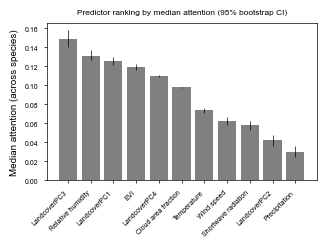

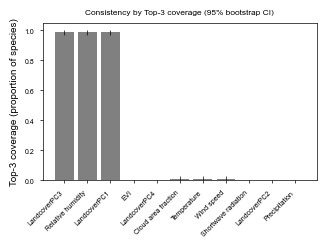

In [20]:
# ---------- 7) Visualizations: bar plots with 95% bootstrap CI ----------
import matplotlib.pyplot as plt

# Plot 1: Median attention with 95% CI
plt.figure(figsize=mm2inch(80, 60), constrained_layout=True)
order = summary.sort_values("median_attention", ascending=False).index.tolist()
med_vals = summary.loc[order, "median_attention"].values
err_low = med_vals - summary.loc[order, "median_lo95"].values
err_high = summary.loc[order, "median_hi95"].values - med_vals
plt.bar(range(len(order)), med_vals, yerr=[err_low, err_high], color = 'gray')
plt.xticks(range(len(order)), convert_to_env_list_detail(order), rotation=45, ha="right")
plt.ylabel("Median attention (across species)")
plt.title("Predictor ranking by median attention (95% bootstrap CI)")
plot1_path = outdir / "median_attention_CI.pdf"
plt.savefig(plot1_path, dpi=500)
plt.show()

# Plot 2: Top-3 coverage with 95% CI
plt.figure(figsize=mm2inch(80, 60), constrained_layout=True)
cov_vals = summary.loc[order, "top3_coverage"].values
cov_low = summary.loc[order, "coverage_lo95"].values
cov_high = summary.loc[order, "coverage_hi95"].values
err_low2 = cov_vals - cov_low
err_high2 = cov_high - cov_vals
plt.bar(range(len(order)), cov_vals, yerr=[err_low2, err_high2], color = 'grey')
plt.xticks(range(len(order)), convert_to_env_list_detail(order), rotation=45, ha="right")
plt.ylabel("Top-3 coverage (proportion of species)")
plt.title("Consistency by Top-3 coverage (95% bootstrap CI)")
plot2_path = outdir / "top3_coverage_CI.pdf"
plt.savefig(plot2_path, dpi=500)
plt.show()

In [21]:
# ---------- 8) Display results as interactive tables (if possible) ----------
if HAS_ACETOOLS:
    tools.display_dataframe_to_user("Attention summary (with bootstrap CIs, ranks)", summary.reset_index().rename(columns={"index":"variable"}))
    tools.display_dataframe_to_user("Pairwise post-hoc Wilcoxon (Holm-corrected)", posthoc_df)
else:
    print("\n[Attention summary]\n", summary.head(10))
    print("\n[Pairwise post-hoc Wilcoxon (first 20 rows)]\n", posthoc_df.head(20))

# Final small text summary (printed)
print("\n--- Variable selection according to the prior rule ---")
print("Core variables:", core_vars)
print("Extended variables:", extended_vars)
print(f"Friedman test: chi2 = {friedman_stat:.3f}, p = {friedman_p:.3e}")
print("Top statistical group (no other variable significantly greater):", top_group)

# Provide artifact paths for download
print("\nArtifacts:")
print(f" - Summary CSV: {summary_path}")
print(f" - Post-hoc CSV: {posthoc_path}")
print(f" - Selection JSON: {selection_path}")
print(f" - Plot (median CI): {plot1_path}")
print(f" - Plot (coverage CI): {plot2_path}")


[Attention summary]
                 median_attention       q25       q75  top3_coverage  \
landcover_PC03          0.148383  0.122658  0.174518          0.992   
hurs                    0.131270  0.114909  0.145319          0.992   
landcover_PC01          0.125836  0.111961  0.136852          0.992   
EVI                     0.119630  0.109007  0.127114          0.000   
landcover_PC04          0.109851  0.103724  0.112116          0.000   
clt                     0.097942  0.096258  0.098766          0.008   
tas                     0.073640  0.064373  0.082462          0.008   
sfcWind                 0.062919  0.051332  0.075406          0.008   
rsds                    0.058262  0.044624  0.072767          0.000   
landcover_PC02          0.042130  0.027840  0.060490          0.000   

                median_lo95  median_hi95  coverage_lo95  coverage_hi95  \
landcover_PC03     0.140050     0.157751          0.968          1.000   
hurs               0.126310     0.136615        

### Evidence of LandcoverPC01 and LandcoverPC03 are related to FOREST

In [22]:
import rasterio
from rasterio.warp import reproject, calculate_default_transform, Resampling

In [23]:
# Load reference grid to get transform, CRS, and profile
ref_path = os.path.join(PU.conf_path, 'extent_binary.tif')
with rasterio.open(ref_path) as ref:
    dst_transform = ref.transform       # target affine transform
    dst_crs       = ref.crs            # target coordinate reference system
    dst_width     = ref.width          # target width in pixels
    dst_height    = ref.height         # target height in pixels
    base_profile  = ref.profile.copy() # template profile for outputs

In [24]:
# Calculate the landcover raw class of each year (LONG TIME TO PROCESS)
for i, conf in enumerate(PU.DeepSDM_conf.CCI_conf['landcover']):
    for yr in range(conf['year_coverages'][0], conf['year_coverages'][1]+1):
        src_path = f'NETCDF:{os.path.join(conf['raw_env_dir'], conf['filename_template'].replace('[YEAR]', str(yr)))}:{conf['layer_name']}'
        with rasterio.open(src_path) as src:
            src_data      = src.read(1)         # read the data array
            src_transform = src.transform       # source affine transform
            src_nodata = src.nodata
            # if the source CRS is missing, warn and assume reference CRS
            if src.crs is None:
                src_crs = dst_crs
            else:
                src_crs = src.crs

        # Allocate an array for reprojection output
        dest_array = np.full((dst_height, dst_width), -9999, dtype='int32')
        
        # Reproject using nearest-neighbor for categorical data
        reproject(
            source=src_data,
            destination=dest_array,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest,
            src_nodata=src_nodata,
            dst_nodata=-9999
        )

        # Log the image 
        profile = base_profile
        profile.update({
            'driver': 'GTiff',
            'dtype': 'int32',
            'count': 1,
            'nodata': -9999,
            'transform': dst_transform,
            'crs': dst_crs
        })
        with rasterio.open(os.path.join(PU.plot_path_attention, f'landcover_raw_class_{yr}.tif'), 'w', **profile) as dst:
            dst.write(dest_array, 1)

In [25]:
# Cell 1: imports & parameters
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, mannwhitneyu, permutation_test, rankdata
import matplotlib.ticker as mtick

# === Project objects ===
# Assume the PU object is available in the environment (contains df_env_pca and plot_path_attention)
df = PU.df_env_pca

# Years and column naming pattern
YEARS = list(range(2001, 2019))  # 2001–2018 (inclusive)
def pc_col(pc_num, year):
    # Use the Jan 1 column for each year
    return f"landcover_PC{pc_num:02d}_{year}-01-01"  # e.g., landcover_PC01_2001-01-01

# Forest class codes (adjust according to your 37-class schema)
FOREST_CODES = {50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90}  # Example; replace with your forest codes as needed

# Random downsampling cap for compute/plotting (two groups combined ≤ MAX_N; roughly half per group)
MAX_N = 300_000

# Output directory
OUTDIR = PU.plot_path_attention

In [26]:
# Cell 2: Read yearly landcover rasters → flatten to 1D vectors (aligned with df rows)
def read_landcover_codes_for_year(year):
    path = os.path.join(PU.plot_path_attention, f"landcover_raw_class_{year}.tif")
    with rasterio.open(path) as ds:
        arr = ds.read(1)
        flat = arr[PU.extent_binary == 1]  # Mask to study area
    return flat

In [27]:
# Cell 3: pool 2001–2018 across all pixel-years
pc1_forest, pc1_nonforest = [], []
pc3_forest, pc3_nonforest = [], []

for y in YEARS:
    # Read landcover codes
    lc_codes = read_landcover_codes_for_year(y)  # shape = (n_pixels,)
    is_valid_lc = ~np.isnan(lc_codes)
    is_forest = np.isin(lc_codes, list(FOREST_CODES)) & is_valid_lc
    
    # PC columns for the given year (use the Jan 1 column from df)
    col_pc1 = pc_col(1, y)
    col_pc3 = pc_col(3, y)
    if (col_pc1 not in PU.df_env_pca.columns) or (col_pc3 not in PU.df_env_pca.columns):
        raise KeyError(f"Missing columns in PU.df_env_pca: {col_pc1} or {col_pc3}")

    v_pc1 = PU.df_env_pca[col_pc1].to_numpy(np.float64)
    v_pc3 = PU.df_env_pca[col_pc3].to_numpy(np.float64)
    valid_pc1 = np.isfinite(v_pc1)
    valid_pc3 = np.isfinite(v_pc3)
    
    # Per-year per-pixel grouping: Forest vs. Non-forest
    mask1 = is_forest & valid_pc1
    mask0 = (~is_forest) & valid_pc1
    pc1_forest.append(v_pc1[mask1]); pc1_nonforest.append(v_pc1[mask0])
    
    mask1 = is_forest & valid_pc3
    mask0 = (~is_forest) & valid_pc3
    pc3_forest.append(v_pc3[mask1]); pc3_nonforest.append(v_pc3[mask0])

# Concatenate all years
pc1_forest = np.concatenate(pc1_forest) if pc1_forest else np.array([], dtype=float)
pc1_nonforest = np.concatenate(pc1_nonforest) if pc1_nonforest else np.array([], dtype=float)
pc3_forest = np.concatenate(pc3_forest) if pc3_forest else np.array([], dtype=float)
pc3_nonforest = np.concatenate(pc3_nonforest) if pc3_nonforest else np.array([], dtype=float)

# (Optional) Downsample to speed up plotting/permutation
def downsample_pair(x1, x0, max_total=MAX_N, seed=42):
    if max_total is None or max_total <= 0: 
        return x1, x0
    half = max_total // 2
    rng = np.random.default_rng(seed)
    def take(v): 
        return v if v.size <= half else v[rng.choice(v.size, size=half, replace=False)]
    return take(x1), take(x0)

pc1_forest_ds, pc1_nonforest_ds = downsample_pair(pc1_forest, pc1_nonforest, MAX_N)
pc3_forest_ds, pc3_nonforest_ds = downsample_pair(pc3_forest, pc3_nonforest, MAX_N)

# Quick summary
def quick_summ(arr):
    return dict(
        n=arr.size, 
        median=float(np.median(arr)),
        q2_5=float(np.percentile(arr, 2.5)),
        q97_5=float(np.percentile(arr, 97.5)),
        unique=int(np.unique(arr).size)
    )

summary = pd.DataFrame({
    "PC1_forest": quick_summ(pc1_forest),
    "PC1_nonforest": quick_summ(pc1_nonforest),
    "PC3_forest": quick_summ(pc3_forest),
    "PC3_nonforest": quick_summ(pc3_nonforest),
}).T
summary

,n,median,q2_5,q97_5,unique
PC1_forest,500119.0,0.429250,0.429250,0.429250,3.0
PC1_nonforest,328403.0,-0.629397,-0.750536,-0.508090,16.0
PC3_forest,500119.0,-0.013040,-0.013040,-0.013040,3.0
PC3_nonforest,328403.0,0.111924,-0.527606,0.725865,16.0


In [28]:
# Cell 4: Cliff's delta, bootstrap CI, permutation p, Mann–Whitney U
def cliffs_delta(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    r = rankdata(np.concatenate([x, y]), method="average")
    r1 = r[:nx].sum()
    A12 = (r1 / nx - (nx + 1)/2) / ny  # Vargha–Delaney A
    return 2*A12 - 1  # Cliff's δ

def bootstrap_ci_delta(x, y, B=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    nx, ny = len(x), len(y)
    boots = np.empty(B)
    for b in range(B):
        xb = x[rng.integers(0, nx, nx)]
        yb = y[rng.integers(0, ny, ny)]
        boots[b] = cliffs_delta(xb, yb)
    lo, hi = np.quantile(boots, [alpha/2, 1 - alpha/2])
    return float(lo), float(hi)

# Replacement permutation test for Cliff's delta: subsample when samples are huge
def perm_test_cliff(x, y, B=10_000, seed=42, max_perm_n=20_000):
    """
    Permutation test for Cliff’s delta.
    If len(x)+len(y) > max_perm_n, randomly downsample each group to half of max_perm_n,
    then run B permutations. Otherwise run the test on the full samples.
    """
    import numpy as np
    from scipy.stats import permutation_test

    n_total = len(x) + len(y)
    rng = np.random.default_rng(seed)

    # Downsample if samples are too large
    if n_total > max_perm_n:
        half = max_perm_n // 2
        x = x if len(x) <= half else rng.choice(x, half, replace=False)
        y = y if len(y) <= half else rng.choice(y, half, replace=False)

    def stat(a, b):
        return cliffs_delta(a, b)

    # Use SciPy's permutation_test (usually optimized)
    res = permutation_test(
        (x, y), stat,
        permutation_type="independent",
        alternative="two-sided",
        n_resamples=B,
        random_state=seed
    )
    return float(res.statistic), float(res.pvalue)


rows = []
for name, x1, x0 in [("PC1", pc1_forest_ds, pc1_nonforest_ds),
                     ("PC3", pc3_forest_ds, pc3_nonforest_ds)]:
    delta = cliffs_delta(x1, x0)
    lo, hi = bootstrap_ci_delta(x1, x0)
    stat, pperm = perm_test_cliff(x1, x0)
    mwu = mannwhitneyu(x1, x0, alternative="two-sided", method="auto")
    rows.append({
        "variable": name,
        "n_forest": int(x1.size), "n_nonforest": int(x0.size),
        "median_forest": float(np.median(x1)), "median_nonforest": float(np.median(x0)),
        "q02_5_forest": float(np.percentile(x1, 2.5)), "q02_5_nonforest": float(np.percentile(x0, 2.5)),
        "q97_5_forest": float(np.percentile(x1, 97.5)), "q97_5_nonforest": float(np.percentile(x0, 97.5)),
        "cliffs_delta": float(delta), "cliffs_delta_lo95": float(lo), "cliffs_delta_hi95": float(hi),
        "perm_statistic_delta": float(stat), "perm_pvalue_two_sided": float(pperm),
        "mannwhitney_u": float(mwu.statistic), "mannwhitney_p_two_sided": float(mwu.pvalue),
    })
effects = pd.DataFrame(rows)
display(effects)
effects.to_csv(os.path.join(OUTDIR, "cc_effects.csv"), index=False)
summary.to_csv(os.path.join(OUTDIR, "cc_summary.csv"))

,variable,n_forest,n_nonforest,median_forest,median_nonforest,q02_5_forest,q02_5_nonforest,q97_5_forest,q97_5_nonforest,cliffs_delta,cliffs_delta_lo95,cliffs_delta_hi95,perm_statistic_delta,perm_pvalue_two_sided,mannwhitney_u,mannwhitney_p_two_sided
0,PC1,150000,150000,0.42925,-0.629397,0.42925,-0.750536,0.42925,-0.508090,0.999995,0.999994,0.999996,0.999993,0.0002,2.249994e+10,0.0
1,PC3,150000,150000,-0.01304,0.111924,-0.01304,-0.527606,-0.01304,0.725865,-0.082901,-0.088036,-0.077887,-0.071993,0.0002,1.031736e+10,0.0


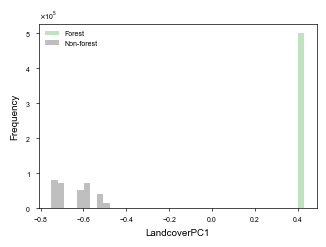

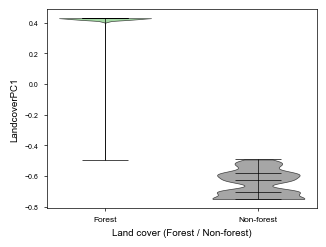

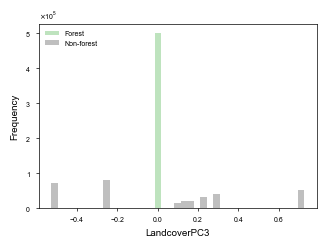

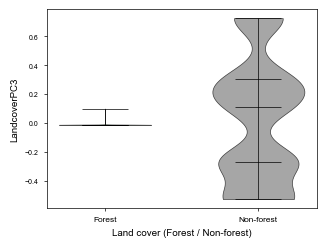

In [29]:
# Cell 5: plots
def plot_kde_or_hist(x1, x0, xlabel, path=None):
    fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)
    u1, u0 = np.unique(x1).size, np.unique(x0).size

    if u1 >= 5 and u0 >= 5:
        # Use KDE when both groups have ≥5 unique values
        grid = np.linspace(min(x1.min(), x0.min()), max(x1.max(), x0.max()), 400)
        ax.plot(grid, gaussian_kde(x1)(grid), label="Forest", color=color_list[0])
        ax.plot(grid, gaussian_kde(x0)(grid), label="Non-forest", color=color_list[1])
    else:
        # Fall back to histograms with shared bins
        all_data = np.concatenate([x1, x0])
        bins = np.linspace(all_data.min(), all_data.max(), 40)  # adjust bin count if needed
        ax.hist(x1, bins=bins, density=False, alpha=0.5, label="Forest", color=color_list[0])
        ax.hist(x0, bins=bins, density=False, alpha=0.5, label="Non-forest", color=color_list[1])
        formatter = mtick.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)

    # Optional: median and CI markers (lines disabled by default)
    for i, arr in enumerate([x1, x0]):
        med = np.median(arr)
        ql = np.percentile(arr, 2.5)
        qh = np.percentile(arr, 97.5)
        # ax.axvline(med, linestyle="--", color=color_list[i])

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.legend(loc='upper left')

    if path:
        fig.savefig(path, dpi=500, transparent=True)
    plt.show()


def plot_violin(x1, x0, ylabel, path=None):
    # x1: Forest, x0: Non-forest
    fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)

    # Violin with medians, extrema, and IQR quantiles (0.25, 0.75)
    violin = ax.violinplot(
        [x1, x0],
        showmeans=False,
        showmedians=True,
        showextrema=True,
        widths=0.6,
        quantiles=[[0.25, 0.75], [0.25, 0.75]],
        bw_method=0.25
    )

    # Style bodies
    for i, body in enumerate(violin['bodies']):
        body.set_facecolor(color_list[i])
        body.set_alpha(0.7)
        body.set_edgecolor('black')
        body.set_linewidth(0.5)

    # Style common violin elements (lines)
    for c_element in [violin['cmaxes'], violin['cmins'], violin['cbars'], violin['cmedians'], violin['cquantiles']]:
        c_element.set_linewidth(0.5)
        c_element.set_color('black')

    # Axes labels & ticks
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Forest", "Non-forest"], size=6)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Land cover (Forest / Non-forest)")

    if path:
        fig.savefig(path, dpi=500, transparent=True)
    plt.show()


color_list = ['#7fc97f', 'grey']

# Use the downsampled arrays produced in Cell 3 for faster plotting
# PC1
plot_kde_or_hist(pc1_forest_ds, pc1_nonforest_ds, xlabel="LandcoverPC1",
                 path=os.path.join(OUTDIR, "pc1_kde_or_hist.pdf"))
plot_violin(pc1_forest_ds, pc1_nonforest_ds, ylabel="LandcoverPC1",
            path=os.path.join(OUTDIR, "pc1_violin.pdf"))

# PC3
plot_kde_or_hist(pc3_forest_ds, pc3_nonforest_ds, xlabel="LandcoverPC3",
                 path=os.path.join(OUTDIR, "pc3_kde_or_hist.pdf"))
plot_violin(pc3_forest_ds, pc3_nonforest_ds, ylabel="LandcoverPC3",
            path=os.path.join(OUTDIR, "pc3_violin.pdf"))

### Forest habitat

In [30]:
# Retrieve habitat designations (forest vs non-forest) for each species in the order of df_attention_order.
habitat = PU.get_species_habitat(df_attention_order)

In [31]:
import pandas as pd
import numpy as np

# 1) Convert the habitat list into a Series aligned with df_attention_order
hab_s = pd.Series(habitat, index=df_attention_order.index, name='Habitat')

# 2) Sum of each habitat — equal to the number of species in that habitat 
#    (since each species contributes one row with total sum = 1)
attn_sum_by_hab = df_attention_order.groupby(hab_s).sum().sort_index()

# 3) Mean of each habitat — equivalent to dividing the summed values by 
#    the number of species in each habitat (same as .mean())
attn_mean_by_hab = df_attention_order.groupby(hab_s).mean().sort_index()

# 4) Proportion within each habitat — normalize each habitat’s total so 
#    that the sum across environmental variables equals 1
#    (row-normalization of the habitat-level sums)
attn_prop_by_hab = attn_sum_by_hab.div(attn_sum_by_hab.sum(axis=1), axis=0)

# 5) Alignment checks (recommended sanity checks)
assert len(habitat) == len(df_attention_order)
assert np.allclose(attn_sum_by_hab.sum(axis=1).values, hab_s.value_counts().sort_index().values)

# 6) Extract the top three most important environmental variables 
#    (by proportion) for each habitat
top3_each_hab = (
    attn_prop_by_hab
      .stack()                                # → Long-format index (Habitat, Env)
      .groupby(level=0)                       # Group by habitat
      .apply(lambda s: s.sort_values(ascending=False).head(3))
)


In [32]:
import pandas as pd
import numpy as np

# Alignment check (optional but recommended)
assert len(habitat) == len(df_attention_order)

# Convert habitat list into a Series aligned with species index
hab_s = pd.Series(habitat, index=df_attention_order.index, name='Habitat')

# Count the number of species in each habitat
n_by_hab = hab_s.value_counts().sort_index()
print(n_by_hab)

# Save to CSV file (optional)
n_by_hab.rename_axis('Habitat').to_frame('n_species').to_csv('n_species_by_habitat.csv')


Habitat
Habitat_DrylandFarming            1
Habitat_Forest                   87
Habitat_ForestEdge               11
Habitat_FreshwaterLakesPools      1
Habitat_MiddleUpperOfStream       5
Habitat_PermanentInlandDeltas     4
Habitat_RockyShoreline            1
Habitat_Shortgrass                5
Habitat_Shrubland                 4
Habitat_Tallgrass                 2
Name: count, dtype: int64


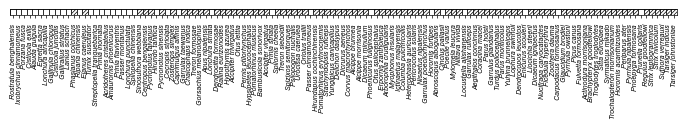

In [33]:
# Create a figure that visually marks forest vs non-forest species using hatching.
# Each rectangle in the figure is hatched or not based on the habitat.

forest_hatch = '/////////'
non_forest_hatch = ''
fig, ax = plt.subplots(figsize = mm2inch(180, 30), gridspec_kw = {'left': 0.05, 'right': 0.99, 'bottom': 0.93, 'top': 0.98})

for i, h in enumerate(habitat):
    if h == 'Habitat_Forest':
        rect = mpatches.Rectangle(
            (i, 0), 1, 1,      
            facecolor='white', 
            edgecolor='black', 
            hatch=forest_hatch,
            linewidth = 0.5
        )
    else:
        rect = mpatches.Rectangle(
            (i, 0), 1, 1,
            facecolor='white',
            edgecolor='black',
            hatch=non_forest_hatch,
            linewidth = 0.5
        )
    ax.add_patch(rect)

ax.set_xlim(0, len(habitat))
ax.set_ylim(0, 1)
ax.set_xticks(range(len(habitat)))
ax.set_xticks(np.arange(len(df_attention_order.index))+0.5)
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_yticks([])

plot_output = os.path.join(PU.plot_path_attention, 'forest.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Attention score by environmental factors

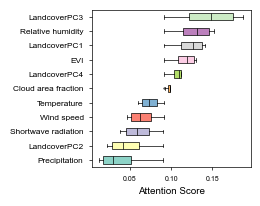

In [34]:
# Draw boxplots for each environmental factor across all species.
# The custom color list is used to distinguish different factors.
fig, ax = plt.subplots(figsize = mm2inch(65, 50), gridspec_kw = {'left': 0.33, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})
box = ax.boxplot(df_attention_order.values, vert = False, patch_artist = True, tick_labels = df_attention_order.columns,
                 medianprops = dict(color = 'black'),
                )

for patch, label in zip(box['boxes'], df_attention_order.columns):
    patch.set_facecolor(custom_cmap[label])
    patch.set_edgecolor('black')

ax.set_xlabel("Attention Score")
ax.set_yticklabels(list(df_attention_order.columns), fontsize = 6)

plot_output = os.path.join(PU.plot_path_attention, 'attention_boxplot_by_env.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Correlation of "hurs" with average elevation

In [35]:
# Load a table of average elevation for each species.
avg_elevation = pd.read_csv(PU.avg_elev_path)

0.9686966535699767 7.381089204088849e-74


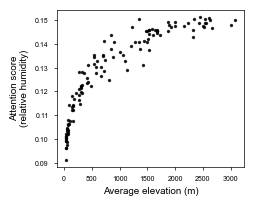

In [36]:
# Scatter plot of average elevation vs. the attention score for "Cloud area fraction".
# Spearman correlation is calculated.

fig, ax = plt.subplots(figsize=mm2inch(65, 50), gridspec_kw = {'left': 0.22, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})
ax.scatter(x = [avg_elevation.AverageElevation[avg_elevation.Species == sp.replace(' ', '_')].tolist()[0] for sp in df_attention_order.index],
           y = df_attention_order['Relative humidity'], 
           c = 'black', 
           alpha = 0.8, 
           s = 2)
ax.set_xlabel('Average elevation (m)')
ax.set_ylabel('Attention score\n(relative humidity)')
rho_cltelev, p_cltelev = spearmanr([avg_elevation.AverageElevation[avg_elevation.Species == sp.replace(' ', '_')].tolist()[0] for sp in df_attention_order.index], 
                                   df_attention_order['Relative humidity'])
print(rho_cltelev, p_cltelev)

plot_output = os.path.join(PU.plot_path_attention, 'atthurs_elev.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Boxplot: Forest vs Non-forest

In [37]:
# Compare LandcoverPC1 attention scores between forest-habitat species and non-forest species.
# Conduct a t-test to determine statistical significance.
forest_values = df_attention_order['LandcoverPC3'][np.array(habitat) == 'Habitat_Forest']
non_forest_values = df_attention_order['LandcoverPC3'][np.array(habitat) != 'Habitat_Forest']
t_stat, p_value = ttest_ind(forest_values, non_forest_values)
significance_star = get_significance_stars(p_value)

print(t_stat, p_value)

7.058842683694505 1.2085411999876755e-10


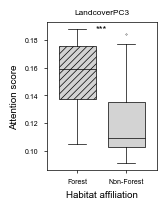

In [38]:
# Generate side-by-side boxplots for forest and non-forest LandcoverPC1 attention scores.
# The function set_box_color is used to style the boxes with or without hatch.

def set_box_color(bp, hatch=None):
    for patch in bp['boxes']:
        patch.set_edgecolor('black')
        patch.set_facecolor('lightgrey')
        if hatch:
            patch.set_hatch(hatch)
    for whisker in bp['whiskers']:
        whisker.set_color('black')
    for cap in bp['caps']:
        cap.set_color('black')
    for median in bp['medians']:
        median.set_color('black')

positions_forest = [-0.4]
positions_non_forest = [0.4]

fig, ax = plt.subplots(figsize = mm2inch(40, 50), gridspec_kw = {'left': 0.25, 'right': 0.95, 'bottom': 0.15, 'top': 0.90})

bp_forest = ax.boxplot([forest_values], positions = positions_forest, sym = '.', widths = 0.6, patch_artist = True)
bp_non_forest = ax.boxplot([non_forest_values], positions = positions_non_forest, sym = '.', widths = 0.6, patch_artist = True)

set_box_color(bp_forest, hatch='/////')  
set_box_color(bp_non_forest)

x_pos = 0
y_max = max(np.max(forest_values), np.max(non_forest_values))
ax.text(x_pos, y_max-0.003, significance_star, ha = 'center', va = 'bottom', fontsize = 7, color = 'black')

ax.set_xticks([-0.4, 0.4])
ax.set_xticklabels(['Forest', 'Non-Forest'])
ax.set_ylabel("Attention score")
ax.set_ylim(min(forest_values.min(), non_forest_values.min()) - 0.005, 
            max(forest_values.max(), non_forest_values.max()) + 0.005)
ax.set_title("LandcoverPC3")
ax.set_xlabel("Habitat affiliation")

plot_output = os.path.join(PU.plot_path_attention, 'forest_nonforest_landcoverPC3.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

In [39]:
# Compare LandcoverPC1 attention scores between forest-habitat species and non-forest species.
# Conduct a t-test to determine statistical significance.
forest_values = df_attention_order['LandcoverPC1'][np.array(habitat) == 'Habitat_Forest']
non_forest_values = df_attention_order['LandcoverPC1'][np.array(habitat) != 'Habitat_Forest']
t_stat, p_value = ttest_ind(forest_values, non_forest_values)
significance_star = get_significance_stars(p_value)

print(t_stat, p_value)

7.671543243007108 5.162794977920167e-12


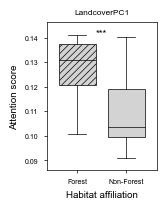

In [40]:
# Generate side-by-side boxplots for forest and non-forest LandcoverPC1 attention scores.
# The function set_box_color is used to style the boxes with or without hatch.

def set_box_color(bp, hatch=None):
    for patch in bp['boxes']:
        patch.set_edgecolor('black')
        patch.set_facecolor('lightgrey')
        if hatch:
            patch.set_hatch(hatch)
    for whisker in bp['whiskers']:
        whisker.set_color('black')
    for cap in bp['caps']:
        cap.set_color('black')
    for median in bp['medians']:
        median.set_color('black')

positions_forest = [-0.4]
positions_non_forest = [0.4]

fig, ax = plt.subplots(figsize = mm2inch(40, 50), gridspec_kw = {'left': 0.25, 'right': 0.95, 'bottom': 0.15, 'top': 0.90})

bp_forest = ax.boxplot([forest_values], positions = positions_forest, sym = '.', widths = 0.6, patch_artist = True)
bp_non_forest = ax.boxplot([non_forest_values], positions = positions_non_forest, sym = '.', widths = 0.6, patch_artist = True)

set_box_color(bp_forest, hatch='/////')  
set_box_color(bp_non_forest)

x_pos = 0
y_max = max(np.max(forest_values), np.max(non_forest_values))
ax.text(x_pos, y_max-0.001, significance_star, ha = 'center', va = 'bottom', fontsize = 7, color = 'black')

ax.set_xticks([-0.4, 0.4])
ax.set_xticklabels(['Forest', 'Non-Forest'])
ax.set_ylabel("Attention score")
ax.set_ylim(min(forest_values.min(), non_forest_values.min()) - 0.005, 
            max(forest_values.max(), non_forest_values.max()) + 0.005)
ax.set_title("LandcoverPC1")
ax.set_xlabel("Habitat affiliation")

plot_output = os.path.join(PU.plot_path_attention, 'forest_nonforest_landcoverPC1.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

In [41]:
PU.coocc_counts[PU.coocc_counts.counts != 0]

,sp1,sp2,counts
0,Abroscopus_albogularis,Acanthis_flammea,3
1,Abroscopus_albogularis,Accipiter_badius,12
2,Abroscopus_albogularis,Accipiter_gentilis,130
3,Abroscopus_albogularis,Accipiter_gularis,219
4,Abroscopus_albogularis,Accipiter_nisus,182
...,...,...,...
107792,Zosterops_erythropleurus,Zosterops_meyeni,2
107793,Zosterops_erythropleurus,Zosterops_simplex,52
107794,Zosterops_japonicus,Zosterops_meyeni,23
107795,Zosterops_japonicus,Zosterops_simplex,46557


### Corelation between environmental factor value and attention score (沒用到)

In [100]:
env_value_all = {}
for i, env in enumerate(PU.env_list_detail):
    env_folder = f'./workspace/raster_data/env_aligned_timespan_avg/{PU.env_list[i]}'
    files = os.listdir(env_folder)
    env_value = []
    for file in files:
        with rasterio.open(os.path.join(env_folder, file), 'r') as f:
            img = f.read(1)
        img = img[img != -9999]
        env_value.append(img)
    env_values = np.concatenate(env_value)
    if PU.env_list[i] not in PU.DeepSDM_conf.training_conf['non_normalize_env_list']:
        env_values = (env_values - PU.env_info['info'][PU.env_list[i]]['mean'])/PU.env_info['info'][PU.env_list[i]]['sd']
    env_value_all[env] = env_values
    

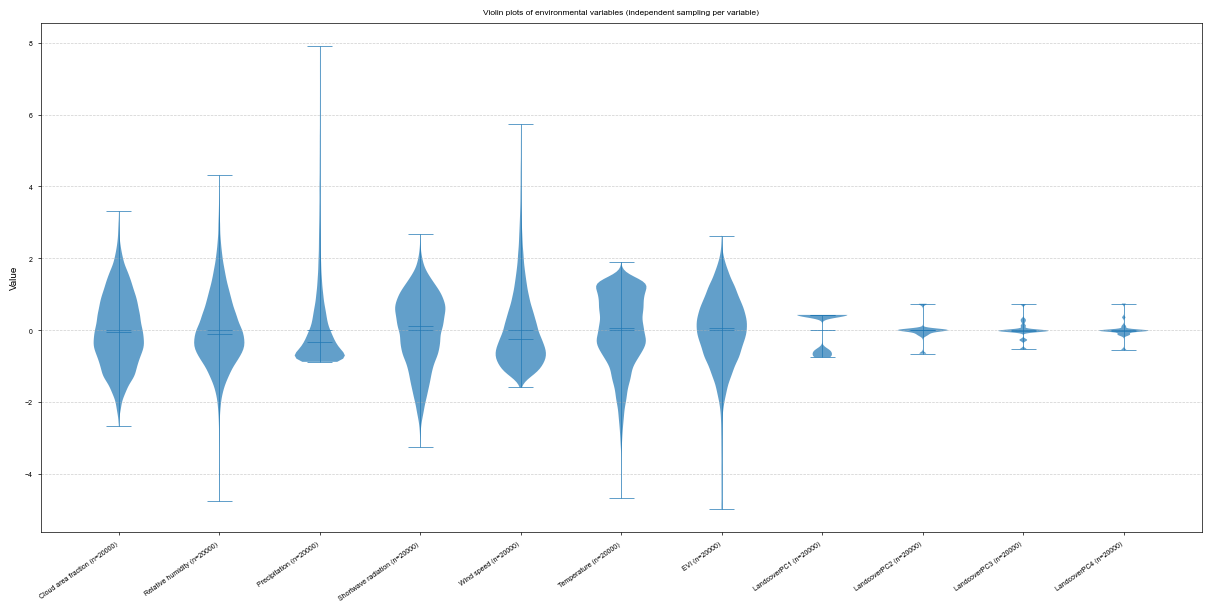

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# -------- 參數 --------
sample_size = 20000                 # 每個變數最多抽樣數量，可依記憶體調整
rng = np.random.default_rng(42)     # 固定亂數種子（可改/移除）
order = PU.env_list_detail
# 只保留實際存在的鍵；若沒有指定順序，就直接用 dict 的鍵順序
order = [k for k in order if k in env_value_all] or list(env_value_all.keys())

def clean_and_sample(arr, nmax, rng):
    a = np.asarray(arr)
    a = a[np.isfinite(a)]           # 去除 NaN/Inf
    if a.size == 0:
        return a
    n = min(nmax, a.size)
    idx_local = rng.choice(a.size, size=n, replace=False)  # 各變數各抽各的
    return a[idx_local]

# -------- 準備資料（各自獨立抽樣）--------
data, labels = [], []
for k in order:
    sampled = clean_and_sample(env_value_all[k], sample_size, rng)
    if sampled.size > 0:
        data.append(sampled)
        labels.append(f"{k} (n={sampled.size})")

# -------- 作圖（純 matplotlib）--------
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

parts = ax.violinplot(
    dataset=data, 
    showmeans=True, 
    showmedians=True, 
    showextrema=True
)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_title("Violin plots of environmental variables (independent sampling per variable)")
ax.set_ylabel("Value")

# 小提琴透明度微調（不指定顏色，照預設）
for pc in parts['bodies']:
    pc.set_alpha(0.7)
ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

plt.show()


Spearman correlation between IQR and mean attention:
ρ = -0.137, p = 6.886e-01


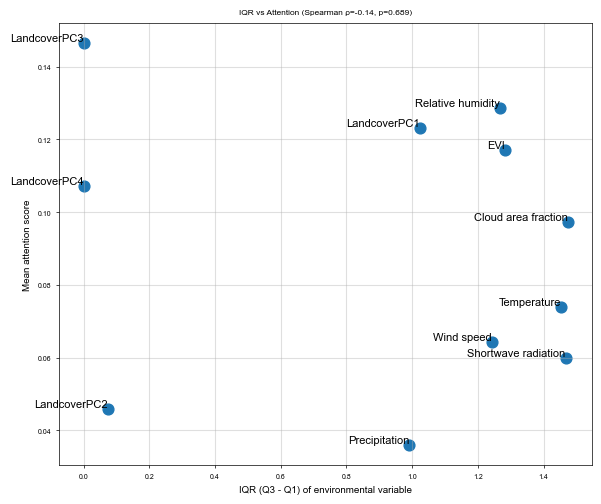

,Q1,Q3,IQR,Mean_attention,logIQR
Cloud area fraction,-0.750343,0.723099,1.473442,0.097296,0.168333
Relative humidity,-0.665872,0.601172,1.267044,0.128723,0.102792
Precipitation,-0.680690,0.310717,0.991407,0.035920,-0.003748
Shortwave radiation,-0.698884,0.767955,1.466839,0.059773,0.166382
Wind speed,-0.737138,0.505581,1.242719,0.064317,0.094373
Temperature,-0.621879,0.831016,1.452895,0.074011,0.162234
EVI,-0.594349,0.688391,1.282740,0.117059,0.108139
LandcoverPC1,-0.594043,0.429250,1.023293,0.123196,0.010000
LandcoverPC2,-0.065891,0.008600,0.074490,0.045809,-1.127899
LandcoverPC3,-0.013040,-0.013040,0.000000,0.146608,-8.000000


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# === 1. 計算每個環境因子的 IQR ===
records = []
for k, arr in env_value_all.items():
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]  # 去除 NaN / Inf
    if arr.size == 0:
        continue
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    records.append({"Variable": k, "Q1": q1, "Q3": q3, "IQR": iqr})

df_iqr = pd.DataFrame(records).set_index("Variable")

# === 2. 計算 attention score 的平均值 ===
# 假設 df_attention_order 的欄位名稱與 env_value_all 的 key 對應（例如 Precipitation, LandcoverPC1 ...）
df_attention_mean = df_attention_order.mean(axis=0).to_frame("Mean_attention")

# === 3. 合併兩者 ===
df_compare = pd.concat([df_iqr, df_attention_mean], axis=1, join="inner").dropna()
df_compare["logIQR"] = np.log10(df_compare["IQR"] + 1e-8)  # 為了看趨勢可取 log

# === 4. 計算相關係數 ===
rho, pval = spearmanr(df_compare["IQR"], df_compare["Mean_attention"])
print("Spearman correlation between IQR and mean attention:")
print(f"ρ = {rho:.3f}, p = {pval:.3e}")

# === 5. 畫圖 ===
plt.figure(figsize=(6, 5))
plt.scatter(df_compare["IQR"], df_compare["Mean_attention"], s=60)
for name, row in df_compare.iterrows():
    plt.text(row["IQR"], row["Mean_attention"], name, fontsize=8, ha="right", va="bottom")

plt.xlabel("IQR (Q3 - Q1) of environmental variable")
plt.ylabel("Mean attention score")
plt.title(f"IQR vs Attention (Spearman ρ={rho:.2f}, p={pval:.3g})")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

df_compare


### Check if nest structures are related to attention scores of RELATIVE HUMIDITY (沒用到)

In [48]:
def get_species_nest_structure(df_attention_order):
    """
    Retrieve nest-related information from the trait dataset for each species
    and map them to a final list for plotting/analysis.
    """
    taxon_df = pd.read_csv(PU.traitdataset_taxon_path, delimiter='\t')
    measurement_df = pd.read_csv(PU.traitdataset_mesurement_path, delimiter='\t')
    nest_related_df = measurement_df[
        measurement_df['measurementType'].str.contains('Neststructure', na=False, case=False)
    ]
    merged_nest_df = nest_related_df.merge(taxon_df, left_on='id', right_on='taxonID', how='left')
    merged_nest_df['measurementValue'] = merged_nest_df['measurementValue'].astype(float)
    best_nest = merged_nest_df.loc[merged_nest_df.groupby('taxonID')['measurementValue'].idxmax()]
    species_nest_df = best_nest[['scientificName', 'measurementType']].copy()

    name_to_change = {
        'Porzana fusca': 'Zapornia fusca',
        'Gallirallus striatus': 'Lewinia striata',
        'Stachyridopsis ruficeps': 'Cyanoderma ruficeps',
        'Pomatorhinus erythrocnemis': 'Erythrogenys erythrocnemis',
        'Alcippe brunnea': 'Schoeniparus brunneus',
        'Ictinaetus malayensis': 'Ictinaetus malaiensis',
        'Poecile varius': 'Sittiparus castaneoventris',
        'Parus holsti': 'Machlolophus holsti',
        'Turdus poliocephalus': 'Turdus niveiceps',
        'Garrulax poecilorhynchus': 'Pterorhinus poecilorhynchus',
        'Garrulax ruficeps': 'Pterorhinus ruficeps',
        'Glaucidium brodiei': 'Taenioptynx brodiei',
        'Tarsiger indicus': 'Tarsiger formosanus'
    }

    df_attention_sp_name = list(df_attention_order.index)
    for i, name in enumerate(df_attention_sp_name):
        if name in name_to_change:
            df_attention_sp_name[i] = name_to_change[name]
    nest = []
    for sp in df_attention_sp_name:
        if sp not in species_nest_df.scientificName.tolist():
            nest.append(None)
        else:
            nest.append(species_nest_df.measurementType[species_nest_df.scientificName == sp].values.tolist()[0])

    return nest
nest = get_species_nest_structure(df_attention_order)

In [49]:
open_value = []
closed_value = []
for i, n in enumerate(np.array(nest)):
    if n in ['Neststructure_Scrape', 'Neststructure_Platform', 'Neststructure_Cup']:
        open_value.append(df_attention_order['Relative humidity'].iloc[i])
    else:
        closed_value.append(df_attention_order['Relative humidity'].iloc[i])

In [50]:
ttest_ind(open_value, closed_value)

TtestResult(statistic=-1.2522398871858729, pvalue=0.21293799726467322, df=119.0)